<a href="https://colab.research.google.com/github/sebaspatric/curso-no-parametrica/blob/main/tarea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Descarga el archivo de datos wine.csv. Este dataset lo hemos visto en clases anteriores. En las columnas tienes 5 tipos diferentes de vinos, que han sido calificados por un grupo de jueces. Las calificaciones de cada juez hacia cada tipo de vino son los valores que tienes en cada fila del dataset.

Contesta a las siguientes preguntas. Para ello puedes usar Python o R, el que prefieras.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
import warnings
warnings.filterwarnings("ignore")



In [7]:

link="https://raw.githubusercontent.com/sebaspatric/curso-no-parametrica/refs/heads/main/6.%20Friedman/6.2%20Ejemplo%20Python/wine.csv"


df=pd.read_csv(link)

In [4]:
df.head()

,Judge,pinecreek,saintjude,northnapa,sevenwinds,eternalvalley
0,1.0,6.0,3.0,3.0,5.0,3.0
1,2.0,7.0,4.0,4.0,4.0,4.0
2,3.0,6.0,5.0,4.0,5.0,3.0
3,4.0,7.0,3.0,2.0,4.0,2.0
4,5.0,5.0,4.0,3.0,4.0,4.0


Preguntas de esta tarea
1. ¿De qué tipo son las variables (las columnas) de este dataset? Justifica tu respuesta.

2. Si quisiéramos contrastar si hay diferencias entre las calificaciones obtenidas por los diferentes vinos, ¿podríamos usar un método paramétrico? Justifica tu respuesta.

3. Si quisiéramos contrastar si los jueces están de acuerdo en sus calificaciones, ¿podríamos usar un método paramétrico? Justifica tu respuesta.

4. Para ambas preguntas anteriores, ¿podríamos usar un método no paramétrico? Justifica tu respuesta.

5. Si queremos contrastar si los jueces están de acuerdo en sus calificaciones, con un método no paramétrico, ¿qué nombre tiene ese método?

6. Para aplicar ese método, fíjate que la pregunta se refiere a los jueces, no a los vinos como vimos en el ejemplo de clase. Como los jueces están en las filas de la matriz de datos, no en las columnas, ¿qué transformación debemos hacerle a la matriz de datos para poder aplicar después el test no paramétrico?

7. Después de hacer la transformación, realiza el test no paramétrico para saber si los jueces están de acuerdo en sus calificacione. ¿Qué p-valor has obtenido? ¿A qué conclusión llegas?

8. Realiza un boxplot múltiple, para obtener 10 boxplot diferentes en el mismo gráfico, y ver visualmente si hay diferencias entre los criterios de los jueces. Copia y pega aquí la imagen que has obtenido.

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Judge          10 non-null     float64
 1   pinecreek      10 non-null     float64
 2   saintjude      10 non-null     float64
 3   northnapa      10 non-null     float64
 4   sevenwinds     10 non-null     float64
 5   eternalvalley  10 non-null     float64
dtypes: float64(6)
memory usage: 612.0 bytes


In [9]:
import pandas as pd
2
from scipy.stats import shapiro
3
from statsmodels.stats.anova import AnovaRM

In [12]:

link="https://raw.githubusercontent.com/sebaspatric/curso-no-parametrica/refs/heads/main/6.%20Friedman/6.2%20Ejemplo%20Python/wine.csv"


df=pd.read_csv(link)

In [15]:
df

,Judge,pinecreek,saintjude,northnapa,sevenwinds,eternalvalley
0,1.0,6.0,3.0,3.0,5.0,3.0
1,2.0,7.0,4.0,4.0,4.0,4.0
2,3.0,6.0,5.0,4.0,5.0,3.0
3,4.0,7.0,3.0,2.0,4.0,2.0
4,5.0,5.0,4.0,3.0,4.0,4.0
5,6.0,6.0,3.0,3.0,3.0,2.0
6,7.0,7.0,4.0,2.0,5.0,3.0
7,8.0,6.0,3.0,4.0,5.0,3.0
8,9.0,7.0,3.0,3.0,3.0,4.0
9,10.0,5.0,4.0,2.0,4.0,2.0


In [17]:
import pandas as pd
from scipy.stats import shapiro
from statsmodels.stats.anova import AnovaRM

link = "https://raw.githubusercontent.com/sebaspatric/curso-no-parametrica/refs/heads/main/6.%20Friedman/6.2%20Ejemplo%20Python/wine.csv"

df = pd.read_csv(link)

# Formato largo
long = df.melt(
    id_vars='Judge',
    var_name='wine',
    value_name='score'
)

# ANOVA de medidas repetidas
anova = AnovaRM(
    data=long,
    depvar='score',
    subject='Judge',
    within=['wine']
).fit()

# Residuos aproximados
long['media_vino'] = long.groupby('wine')['score'].transform('mean')
long['residuo'] = long['score'] - long['media_vino']

# Shapiro-Wilk sobre residuos
w, p = shapiro(long['residuo'])

print(f"W = {w:.4f}")
print(f"p = {p:.4f}")

if p > 0.05:
    print("No se rechaza la normalidad de los residuos")
else:
    print("Se rechaza la normalidad de los residuos")

W = 0.9293
p = 0.0052
Se rechaza la normalidad de los residuos


In [20]:
import pandas as pd
from scipy.stats import anderson

link = "https://raw.githubusercontent.com/sebaspatric/curso-no-parametrica/refs/heads/main/6.%20Friedman/6.2%20Ejemplo%20Python/wine.csv"

df = pd.read_csv(link)

# Excluir identificador
vinos = df.drop(columns=["Judge"])

for col in vinos.columns:

    resultado = anderson(vinos[col], dist='norm')

    print("\n" + "="*50)
    print(col)
    print(f"A² = {resultado.statistic:.4f}")

    print("\nNivel (%) | Valor crítico")

    for sl, cv in zip(resultado.significance_level,
                      resultado.critical_values):
        print(f"{sl:8.1f} | {cv:.4f}")

    # Decisión al 5%
    idx_5 = list(resultado.significance_level).index(5.0)

    if resultado.statistic < resultado.critical_values[idx_5]:
        print("\nSe acepta la normalidad (α=0.05)")
    else:
        print("\n✗ Se rechaza normalidad (α=0.05)")


pinecreek
A² = 0.7816

Nivel (%) | Valor crítico
    15.0 | 0.5010
    10.0 | 0.5700
     5.0 | 0.6840
     2.5 | 0.7980
     1.0 | 0.9500

✗ Se rechaza normalidad (α=0.05)

saintjude
A² = 1.0268

Nivel (%) | Valor crítico
    15.0 | 0.5010
    10.0 | 0.5700
     5.0 | 0.6840
     2.5 | 0.7980
     1.0 | 0.9500

✗ Se rechaza normalidad (α=0.05)

northnapa
A² = 0.7053

Nivel (%) | Valor crítico
    15.0 | 0.5010
    10.0 | 0.5700
     5.0 | 0.6840
     2.5 | 0.7980
     1.0 | 0.9500

✗ Se rechaza normalidad (α=0.05)

sevenwinds
A² = 0.7816

Nivel (%) | Valor crítico
    15.0 | 0.5010
    10.0 | 0.5700
     5.0 | 0.6840
     2.5 | 0.7980
     1.0 | 0.9500

✗ Se rechaza normalidad (α=0.05)

eternalvalley
A² = 0.7053

Nivel (%) | Valor crítico
    15.0 | 0.5010
    10.0 | 0.5700
     5.0 | 0.6840
     2.5 | 0.7980
     1.0 | 0.9500

✗ Se rechaza normalidad (α=0.05)


3. Si quisiéramos contrastar si los jueces están de acuerdo en sus calificaciones, ¿podríamos usar un método paramétrico? Justifica tu respuesta.

In [28]:
import pandas as pd
from scipy.stats import shapiro

link = "https://raw.githubusercontent.com/sebaspatric/curso-no-parametrica/refs/heads/main/6.%20Friedman/6.2%20Ejemplo%20Python/wine.csv"

df = pd.read_csv(link)

# Solo puntuaciones
scores = df.drop(columns=["Judge"])

print("Normalidad por juez:\n")

for i, fila in scores.iterrows():

    w, p = shapiro(fila.values)

    print(f"Juez {i+1}: W={w:.4f}, p={p:.4f}")

    if p < 0.05:
        print(" -> Se rechaza normalidad")
    else:
        print(" -> No se rechaza normalidad")

Normalidad por juez:

Juez 1: W=0.7667, p=0.0422
 -> Se rechaza normalidad
Juez 2: W=0.5522, p=0.0001
 -> Se rechaza normalidad
Juez 3: W=0.9609, p=0.8140
 -> No se rechaza normalidad
Juez 4: W=0.8422, p=0.1710
 -> No se rechaza normalidad
Juez 5: W=0.8835, p=0.3254
 -> No se rechaza normalidad
Juez 6: W=0.7683, p=0.0435
 -> Se rechaza normalidad
Juez 7: W=0.9787, p=0.9276
 -> No se rechaza normalidad
Juez 8: W=0.9020, p=0.4211
 -> No se rechaza normalidad
Juez 9: W=0.7008, p=0.0098
 -> Se rechaza normalidad
Juez 10: W=0.8519, p=0.2006
 -> No se rechaza normalidad


In [29]:
from scipy.stats import shapiro

for vino in scores.columns:

    w, p = shapiro(scores[vino])

    print(f"{vino}: W={w:.4f}, p={p:.4f}")

pinecreek: W=0.8197, p=0.0251
saintjude: W=0.7809, p=0.0085
northnapa: W=0.8318, p=0.0352
sevenwinds: W=0.8197, p=0.0251
eternalvalley: W=0.8318, p=0.0352


In [30]:
from scipy.stats import friedmanchisquare

# Transponer: filas=vinos, columnas=jueces
judge_matrix = scores.T

stat, p = friedmanchisquare(
    *[judge_matrix[col] for col in judge_matrix.columns]
)

print(f"Chi² = {stat:.4f}")
print(f"p = {p:.4f}")

Chi² = 13.2552
p = 0.1514


In [31]:
if p < 0.05:
    print("Se rechaza H0: existen diferencias entre jueces")
else:
    print("No se rechaza H0: no hay evidencia de diferencias entre jueces")

No se rechaza H0: no hay evidencia de diferencias entre jueces


In [32]:
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import shapiro

# Datos en formato largo
long = scores.T.melt(
    var_name="Judge",
    value_name="Score"
)

# ANOVA con juez como factor
modelo = smf.ols(
    "Score ~ C(Judge)",
    data=long
).fit()

# Residuos reales del modelo
residuos = modelo.resid

# Shapiro-Wilk
W, p = shapiro(residuos)

print(f"W = {W:.4f}")
print(f"p = {p:.4f}")

W = 0.9257
p = 0.0038


5. Si queremos contrastar si los jueces están de acuerdo en sus calificaciones, con un método no paramétrico, ¿qué nombre tiene ese método?



6. Para aplicar ese método, fíjate que la pregunta se refiere a los jueces, no a los vinos como vimos en el ejemplo de clase. Como los jueces están en las filas de la matriz de datos, no en las columnas, ¿qué transformación debemos hacerle a la matriz de datos para poder aplicar después el test no paramétrico?


In [33]:
scores = df.drop(columns=["Judge"])

judge_matrix = scores.T


7. Después de hacer la transformación, realiza el test no paramétrico para saber si los jueces están de acuerdo en sus calificacione. ¿Qué p-valor has obtenido? ¿A qué conclusión llegas?



In [34]:
from scipy.stats import friedmanchisquare

judge_matrix = df.drop(columns=["Judge"]).T

stat, p = friedmanchisquare(
    *[judge_matrix[col] for col in judge_matrix.columns]
)

print("Chi² =", stat)
print("p =", p)

Chi² = 13.255230125523024
p = 0.15139336121542785


In [35]:
import pandas as pd
from scipy.stats import friedmanchisquare

# Cargar datos
link = "https://raw.githubusercontent.com/sebaspatric/curso-no-parametrica/refs/heads/main/6.%20Friedman/6.2%20Ejemplo%20Python/wine.csv"
df = pd.read_csv(link)

# Eliminar identificador
scores = df.drop(columns=["Judge"])

# Transponer la matriz
judge_matrix = scores.T

# Test de Friedman
stat, p = friedmanchisquare(
    *[judge_matrix[col] for col in judge_matrix.columns]
)

print(f"Chi-cuadrado = {stat:.4f}")
print(f"p-valor = {p:.4f}")

# Conclusión
alpha = 0.05

if p < alpha:
    print("\nConclusión:")
    print("Se rechaza H0. Existen diferencias significativas entre los jueces.")
    print("Al menos un juez utiliza un criterio de calificación diferente.")
else:
    print("\nConclusión:")
    print("No se rechaza H0.")
    print("No existe evidencia suficiente para afirmar que los jueces difieran en sus criterios de evaluación.")

Chi-cuadrado = 13.2552
p-valor = 0.1514

Conclusión:
No se rechaza H0.
No existe evidencia suficiente para afirmar que los jueces difieran en sus criterios de evaluación.


8. Realiza un boxplot múltiple, para obtener 10 boxplot diferentes en el mismo gráfico, y ver visualmente si hay diferencias entre los criterios de los jueces. Copia y pega aquí la imagen que has obtenido.

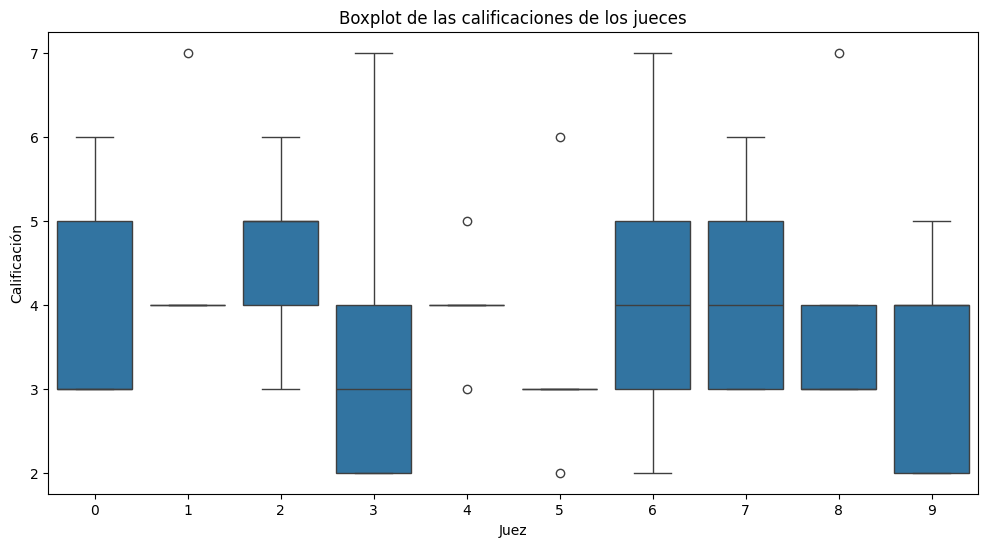

In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

link = "https://raw.githubusercontent.com/sebaspatric/curso-no-parametrica/refs/heads/main/6.%20Friedman/6.2%20Ejemplo%20Python/wine.csv"

df = pd.read_csv(link)

scores = df.drop(columns=["Judge"])

judge_matrix = scores.T

long = judge_matrix.melt(
    var_name="Juez",
    value_name="Calificación"
)

plt.figure(figsize=(12,6))
sns.boxplot(data=long, x="Juez", y="Calificación")

plt.title("Boxplot de las calificaciones de los jueces")
plt.show()